# Example: how to train the TTOA-NN model?

This notebook is a compact example to the training workflow of the TTOA-NN model used in the paper. This example trains one configured model.

In practice, you must tune the following parameters:

* number of hidden layers, per model component
* number of nodes per hidden layer
* batch size
* number of epochs
* learning rate
* dropout rate
* weight decay
* type of activation function (optional)

For the complete overview of the hyperparameter search grid that we used, please see Appendix C: https://dx.doi.org/10.2139/ssrn.7276298

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader

from ttoann.dataloader import ChoiceData
from ttoann.model import TTOA_NN
from ttoann.utils import evaluate_model, get_device, set_seed, train_model

#------------------------------------------------------------------------
# Set up the repository root and import the model and dataloader modules
#------------------------------------------------------------------------

repo_root = Path.cwd()

if not (repo_root / "ttoann").exists():
    repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [ ]:
#-----------------------------------------------------------
# Define global parameters, hyperparameters, and file paths
#-----------------------------------------------------------

seed = 1000
model_type = "multitask"
model_pred = "choice-ttoa-full"
num_alts = 2
batch_size = 128
num_epochs = 100
patience = 15 # early stopping threshold
learning_rate = 0.001
weight_decay = 0.0
alpha = 0.5  # tuneable parameter of the auxiliary moral-stance loss

train_path = repo_root / "data" / "train.csv"
val_path = repo_root / "data" / "validation.csv"
checkpoint_path = repo_root / "example_ttoann_state_dict.pth"

set_seed(seed)

# Check if GPU is available and set the device accordingly
device = get_device()
print(f"Using device: {device}")

Using device: mps


In [3]:
#-----------------------------------------------------
# Load dataset and create dataloaders for data splits
#-----------------------------------------------------

train_dataset = ChoiceData(train_path, model_type=model_type, model_pred=model_pred)
val_dataset = ChoiceData(val_path, model_type=model_type, model_pred=model_pred)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

sample = train_dataset[0]
print(f"\nLoaded data:")
print(f"# of observations:", len(train_dataset), "train /", len(val_dataset), "validation")
print("Sample variables:", sorted(sample))
print("# of non-cost attributes:", {key: value.shape for key, value in sample["x_noncost"].items()})
print("Text shape:", sample["text"].shape)

===> Initializing choice-ttoa-full multitask dataset...
===> Dataset initialized!
===> Initializing choice-ttoa-full multitask dataset...
===> Dataset initialized!

Loaded data:
# of observations: 8772 train / 1884 validation
Sample variables: ['respid', 'text', 'text_mask', 'x_cost', 'x_noncost', 'x_taboo', 'y', 'y_2', 'z']
# of non-cost attributes: {'alt1': torch.Size([7]), 'alt2': torch.Size([7])}
Text shape: torch.Size([30])


In [4]:
#------------------------------
# Initialize the TTOA-NN model
#------------------------------

model = TTOA_NN(
    asu_layer_sizes=[7, 16, 8, 1],
    cost_layer_sizes=[1, 4, 1],
    taboo_layer_sizes=[6, 8, 4, 1],
    z_layer_sizes=[16, 8, 4, 8],
    text_layer_sizes=[30, 8, 8],
    ttoa_layer_sizes=[16, 1],
    moral_stance_layer_sizes=[16, 5],
    ttoa_model=True,
    z_model=True,
    text_model=True,
    activ_fn="relu",
    dropout=0.1,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.3, patience=5, min_lr=1e-6
)

print(model)

TTOA_NN(
  (asu_layers): Sequential(
    (ASU_Layer_1): Linear(in_features=7, out_features=16, bias=True)
    (ASU_Activ_1): ReLU()
    (ASU_Layer_2): Linear(in_features=16, out_features=8, bias=True)
    (ASU_Activ_2): ReLU()
    (ASU_Layer_3): Linear(in_features=8, out_features=1, bias=True)
  )
  (cost_layers): Sequential(
    (Cost_Layer_1): Linear(in_features=1, out_features=4, bias=True)
    (Cost_Activ_1): ReLU()
    (Cost_Layer_2): Linear(in_features=4, out_features=1, bias=True)
  )
  (taboo_layers): Sequential(
    (Taboo_Layer_1): Linear(in_features=6, out_features=8, bias=True)
    (Taboo_Activ_1): ReLU()
    (Taboo_Layer_2): Linear(in_features=8, out_features=4, bias=True)
    (Taboo_Activ_2): ReLU()
    (Taboo_Layer_3): Linear(in_features=4, out_features=1, bias=True)
  )
  (z_layers): Sequential(
    (Z_Layer_1): Linear(in_features=16, out_features=8, bias=True)
    (Z_Activ_1): ReLU()
    (Z_Layer_2): Linear(in_features=8, out_features=4, bias=True)
    (Z_Activ_2): ReL

`train_model` optimizes cross-entropy for choice prediction and, when `ALPHA > 0`, adds masked mean-squared error for moral stance prediction. The best validation log-likelihood is checkpointed and restored after early stopping.

In [5]:
#-------------------------
# Train the TTOA-NN model
#-------------------------

training = train_model(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    model_pred=model_pred,
    num_epochs=num_epochs,
    alpha=alpha,
    patience=patience,
    checkpoint_path=checkpoint_path,
)

print(f"\nModel performance:")
print(training["best_metrics"])

Epoch 1/100: 100%|██████████| 69/69 [00:15<00:00,  4.57it/s]


epoch 001 | loss 0.8008 | val LL -1319.04 | rho^2 -0.0111


Epoch 2/100: 100%|██████████| 69/69 [00:03<00:00, 17.62it/s]


epoch 002 | loss 0.6835 | val LL -1261.32 | rho^2 0.0332


Epoch 3/100: 100%|██████████| 69/69 [00:03<00:00, 18.13it/s]


...

epoch 056 | loss 0.6339 | val LL -1215.85 | rho^2 0.0680


Epoch 57/100: 100%|██████████| 69/69 [00:03<00:00, 18.29it/s]


epoch 057 | loss 0.6336 | val LL -1216.07 | rho^2 0.0679


Epoch 58/100: 100%|██████████| 69/69 [00:03<00:00, 18.24it/s]


epoch 058 | loss 0.6331 | val LL -1216.27 | rho^2 0.0677
Early stopping after epoch 58.

Model performance:
{'ll': -1209.8848114013672, 'null_ll': -1304.588523864746, 'rho_squared': 0.07259278364861455, 'n_observations': 1884, 'moral_mse': 0.001062091551467675}



Model performance on validation set:
  ll: -1209.8848
  null_ll: -1304.5885
  rho_squared: 0.0726
  n_observations: 1884.0000
  moral_mse: 0.0011


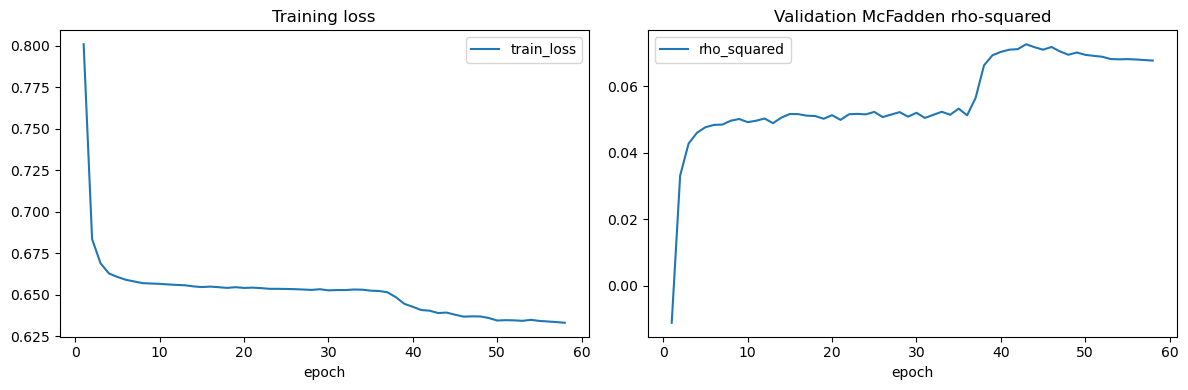

In [6]:
#--------------------------------------------------
# Inspect the training curve and model performance
#--------------------------------------------------

history = pd.DataFrame(training["history"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x="epoch", y="train_loss", ax=axes[0], title="Training loss")
history.plot(x="epoch", y="rho_squared", ax=axes[1], title="Validation McFadden rho-squared")
plt.tight_layout()

final_metrics = evaluate_model(
    model, val_loader, device=device, model_pred=model_pred, num_alts=num_alts
)

print(f"\nModel performance on validation set:")
for metric, value in final_metrics.items():
    print(f"  {metric}: {value:.4f}")

The reported metrics are: model log-likelihood (`ll`), empirical-share null log-likelihood (`null_ll`), and McFadden's rho-squared (`rho_squared`). For the multitask configuration, `moral_mse` is evaluated only on informative documents.